Robin 07/05/2024

# Goal of notebook:

1. Create three optimizers:
* (A) no optimization; charge asap
* (B) get the forecast at plugin time, sort the forecast, charge during minimum windows
* (C) get the actual from 1 day ago, shift it forward 1 day, pretend it's the forecast, do (B)

2. Evaluate them. Write down the assumptions along the way

# Terminology:
* The output of an optimizer is a `plan`

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("../")
from load_data import get_historical_forecast_pandas, get_historical

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [21]:
state = {
    "start": "2024-06-02 02:00Z", # California time: 7pm on 2024/07/01
    "region": "CAISO_NORTH",
}

user = {
    "charge_rate": 4, # units: kW
    "charge_needed": 20, # units: kWh
    "hours_plugged_in": 10, # units: h
}

In [3]:
# output of an optimizer:  'plan', pd.Series, one row per 5 minute interval,
# between event["start"] and 
# for each 5 minute interval, a number in kW of how much we charge
# during that interval. e.g. 0 if we don't charge

def calculate_emissions(plan, state) -> float: # units: lbs CO2
    """
    N.B. this is an 'ex post' calculation,
    we can only calculate this after the plan is finished

    Returns a number: the emissions in units of CO2 lbs
    """
    # pull in actual MOER: units lbs CO2/MWh over time:
    region = state["region"]
    start = plan.index.min().strftime('%Y-%m-%d %H:%MZ')
    end = plan.index.max().strftime('%Y-%m-%d %H:%MZ')
    moer = get_historical(region, start, end).rename(columns={region: "lbs/MWh"})
    df = pd.concat([moer, plan.rename("kW")], axis=1)
    df["MW"] = df["kW"] / 1000
    df["lbs/h"] = df["lbs/MWh"] * df["MW"]
    return df["lbs/h"].sum() / 12 # divide by 12 as each row is 5 mins = (1/12) h

def optimizer_A(user, state):
    """
    no optimization; charge asap
    """
    hours_needed = user["charge_needed"] / user["charge_rate"]
    index = pd.date_range(
        start=state["start"],
        end=pd.Timestamp(state["start"]) + pd.Timedelta(hours=user["hours_plugged_in"]),
        freq="300s",
    )
    # create plan
    plan = [user["charge_rate"]] * math.ceil(12 * hours_needed) # these are the 5m intervals to charge
    plan += [0] * (len(index) - len(plan))
    return pd.Series(index=index, data=plan)

In [9]:
def optimizer_B(user, state):
    """
    get forecast, charge for all the intervals when it's smallest
    """
    # calculate number of 5 min intervals we need to charge in 
    num_intervals = math.ceil(user["charge_needed"] / user["charge_rate"] * 12)

    region = state["region"]
    start = (pd.Timestamp(state["start"]) - pd.Timedelta(days=1)).strftime('%Y-%m-%d %H:%MZ')
    end = (pd.Timestamp(start) + pd.Timedelta(hours=user["hours_plugged_in"])).strftime('%Y-%m-%d %H:%MZ')
    forecast = get_historical_forecast_pandas(region, start, end).rename(columns={region: "MOER"})
    forecast_at_start_col = forecast.columns[0]
    forecast = forecast[[forecast_at_start_col]].rename(columns={forecast_at_start_col: "MOER"})
    forecast = forecast.loc[start: end]
    moer_threshold = forecast.sort_values(by="MOER")["MOER"].iloc[num_intervals]
    plan = (forecast["MOER"] <= moer_threshold).astype(int) * user["charge_rate"]
    return plan

In [17]:
def optimizer_C(user, state):
    """
    get historical from one day ago,
    shift forward by a day,
    treat that as forecast,
    then do optimizer_B
    """
    # calculate number of 5 min intervals we need to charge in 
    num_intervals = math.ceil(user["charge_needed"] / user["charge_rate"] * 12)

    region = state["region"]
    start = (pd.Timestamp(state["start"]) - pd.Timedelta(days=1)).strftime('%Y-%m-%d %H:%MZ')
    end = (pd.Timestamp(start) + pd.Timedelta(hours=user["hours_plugged_in"])).strftime('%Y-%m-%d %H:%MZ')
    forecast = get_historical(region, start, end).rename(columns={region: "MOER"})
    forecast.index = forecast.index + pd.Timedelta(days=1)
    moer_threshold = forecast.sort_values(by="MOER")["MOER"].iloc[num_intervals]
    plan = (forecast["MOER"] <= moer_threshold).astype(int) * user["charge_rate"]
    return plan

In [14]:
plan_A = optimizer_A(user, state)
calculate_emissions(plan_A, state) 

18.471333333333334

In [15]:
plan_B = optimizer_B(user, state)
calculate_emissions(plan_B, state) 

19.139333333333333

In [18]:
plan_C = optimizer_C(user, state)
calculate_emissions(plan_C, state)

19.534000000000002

----

# Visualizations

<Axes: title={'center': 'actual MOER starting at plugin time 2024-06-02 02:00Z'}, xlabel='point_time'>

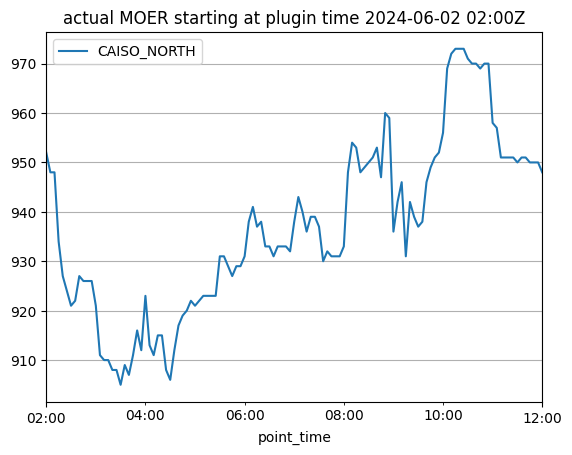

In [23]:
# actual MOER
start = state["start"]
get_historical(
    state["region"],
    start,
    (pd.Timestamp(start) + pd.Timedelta(hours=user["hours_plugged_in"])).strftime('%Y-%m-%d %H:%MZ')
).plot(
    title=f"actual MOER starting at plugin time {start}",
    grid=True,
)

<Axes: title={'center': 'forecasted MOER at plugin time 2024-06-02 02:00Z'}, xlabel='point_time'>

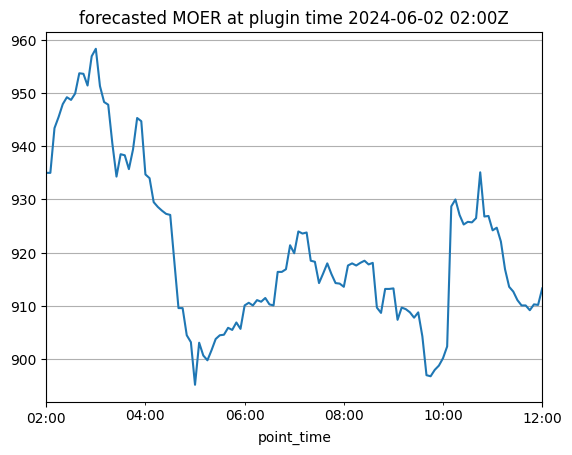

In [27]:
# forecast at plugin time
# actual MOER
start = state["start"]
forecast = get_historical_forecast_pandas(
    state["region"],
    start,
    (pd.Timestamp(start) + pd.Timedelta(hours=user["hours_plugged_in"])).strftime('%Y-%m-%d %H:%MZ')
)
forecast = forecast.loc[:forecast.index.min() + pd.Timedelta(hours=user["hours_plugged_in"])]
forecast[forecast.columns[0]].plot(
    title=f"forecasted MOER at plugin time {start}",
    grid=True,
)

# Todos:

* add tests on output of an optimizer
* make a class for optimizer?
* add more structure to plan: it has a "generated at" attribute, I should keep track of this. Then maybe down the line 